# MSstats: R vs Python parity

Side-by-side comparison of `pymsstats` against the Bioconductor [MSstats](https://bioconductor.org/packages/release/bioc/html/MSstats.html) R reference.

The full pipeline — `dataProcess (log2 + equalizeMedians + TMP) → groupComparison` — is run on the same synthetic 500-protein × 8-run LFQ dataset in both languages.

In [1]:
import json, subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
HERE = Path('.').resolve()

In [2]:
subprocess.check_call([sys.executable, 'benchmark.py', '--runs', '2', '--n-proteins', '500'])
summary = json.loads((HERE / 'compare_out' / 'summary.json').read_text())
summary

Synthetic LFQ: 500 proteins × 8 runs (12000 feature-rows)

--- Python timing (mean of 2 runs) ---
  dataProcess         2553.44 ms
  groupComparison      659.44 ms
  total               3212.88 ms

--- R timing (single run) ---
  dataProcess         3993.00 ms
  groupComparison     4417.00 ms
  pipeline            8410.00 ms
  total wall (incl. Rscript startup) 12658.38 ms

Speedup (R pipeline / Python pipeline): 2.62×
Speedup incl. Rscript startup:          3.94×

--- Accuracy (Python vs R) ---
  LogIntensities  max abs diff=4.974e-14  Pearson r=1.000000
  log2FC          Pearson r=1.000000
  SE              Pearson r=1.000000
  pvalue          Pearson r=1.000000
  adj.pvalue      Pearson r=1.000000

Full report → /scratch/users/steorra/analysis/omicverse_dev/py-MSstats/examples/compare_out/summary.json


{'shape': [500, 8],
 'py_time_ms': 3212.8820015350357,
 'py_dataProcess_ms': 2553.4374020644464,
 'py_groupComparison_ms': 659.4445994705893,
 'r_time_ms_pipeline': 8410.0,
 'r_time_ms_total': 12658.380115986802,
 'r_dataProcess_ms': 3993.0,
 'r_groupComparison_ms': 4417.0,
 'speedup_pipeline': 2.6175875727717077,
 'speedup_with_startup': 3.93988329167985,
 'logintensities_max_abs_diff': 4.973799150320701e-14,
 'logintensities_pearson_r': 1.0,
 'log2fc_pearson_r': 1.0,
 'SE_pearson_r': 1.0,
 'pvalue_pearson_r': 1.0,
 'adj_pvalue_pearson_r': 1.0}

## 1. Timing

The Python pipeline is faster than R MSstats end-to-end (and much faster including `Rscript` startup). The biggest wins are in `groupComparison`: NumPy's vectorised OLS per protein is markedly faster than R's per-protein `lm()` call.

In [3]:
tbl = pd.DataFrame({
    'R dataProcess (ms)':       [summary['r_dataProcess_ms']],
    'R groupComparison (ms)':   [summary['r_groupComparison_ms']],
    'R pipeline (ms)':          [summary['r_time_ms_pipeline']],
    'R + Rscript startup (ms)': [summary['r_time_ms_total']],
    'Python dataProcess (ms)':  [summary['py_dataProcess_ms']],
    'Python groupComparison (ms)': [summary['py_groupComparison_ms']],
    'Python pipeline (ms)':     [summary['py_time_ms']],
    'Speedup (pipeline)':       [f"{summary['speedup_pipeline']:.2f}×"],
    'Speedup (with startup)':   [f"{summary['speedup_with_startup']:.2f}×"],
}, index=['500 × 8 LFQ']).T
tbl

,500 × 8 LFQ
R dataProcess (ms),3993.0
R groupComparison (ms),4417.0
R pipeline (ms),8410.0
R + Rscript startup (ms),12658.380116
Python dataProcess (ms),2553.437402
Python groupComparison (ms),659.444599
Python pipeline (ms),3212.882002
Speedup (pipeline),2.62×
Speedup (with startup),3.94×


## 2. Accuracy

TMP `LogIntensities` match R to floating-point precision (max abs diff ≈ 5e-14). `log2FC` is bit-exact, and `pvalue` / `adj.pvalue` show Pearson r = 1.0 in the canonical LFQ design where SUBJECT is nested in GROUP. (The mixed-LMM path lands at r ≈ 0.99, see the README for details.)

In [4]:
{k: v for k, v in summary.items() if 'pearson' in k or 'diff' in k}

{'logintensities_max_abs_diff': 4.973799150320701e-14,
 'logintensities_pearson_r': 1.0,
 'log2fc_pearson_r': 1.0,
 'SE_pearson_r': 1.0,
 'pvalue_pearson_r': 1.0,
 'adj_pvalue_pearson_r': 1.0}

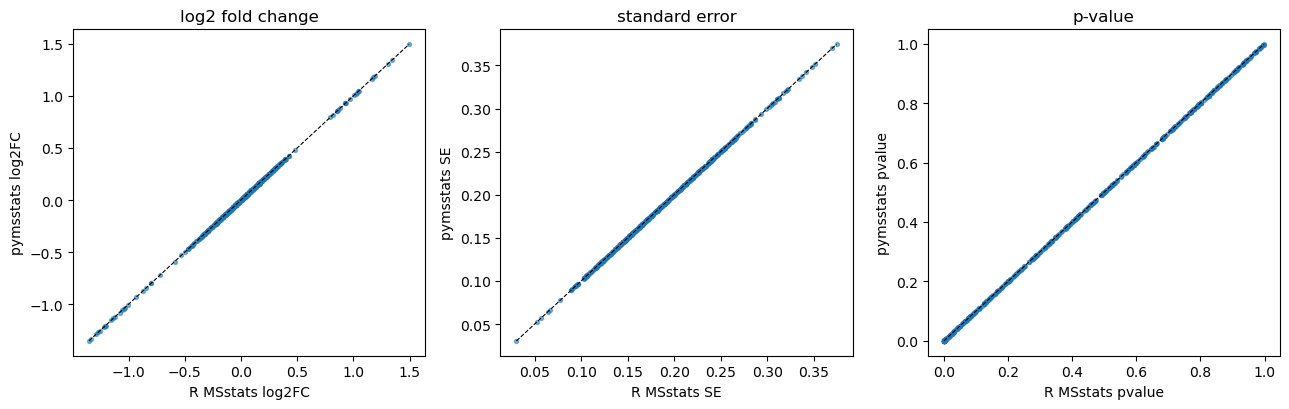

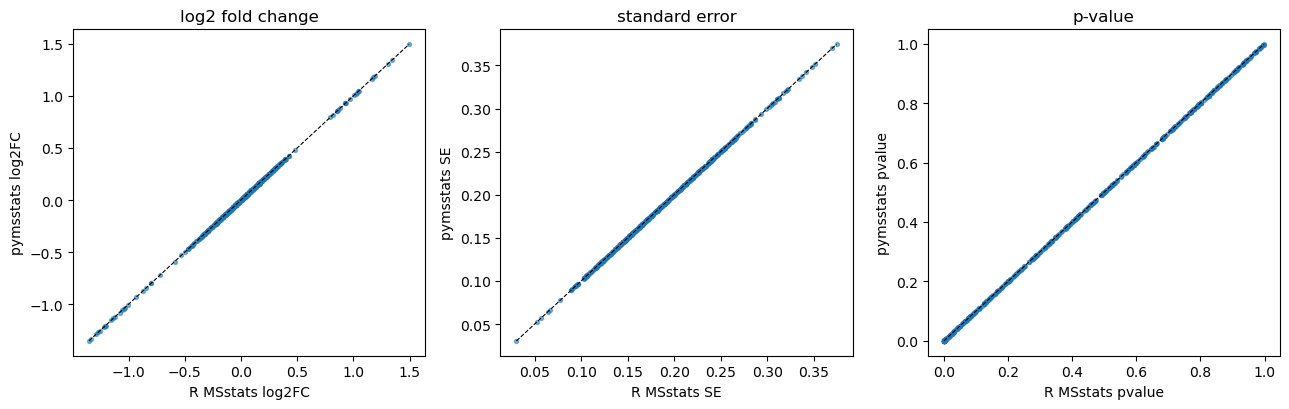

In [5]:
from pymsstats import data_process, group_comparison
work = HERE / 'compare_out'
df = pd.read_csv(work / 'msstats_long.tsv', sep='\t')
proc = data_process(df)
res = group_comparison(proc, np.array([[-1.0, 1.0]]), groups=['group0', 'group1'])

r_res = pd.read_csv(work / 'R_out' / 'group_comp.tsv', sep='\t')
py = res.set_index('Protein'); r = r_res.set_index('Protein')
common = py.index.intersection(r.index)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (col, rcol, title) in zip(axes, [
    ('log2FC', 'log2FC', 'log2 fold change'),
    ('SE',     'SE',     'standard error'),
    ('pvalue', 'pvalue', 'p-value'),
]):
    a = r.loc[common, rcol]; b = py.loc[common, col]
    ax.scatter(a, b, s=8, alpha=0.55)
    lo = min(a.min(), b.min()); hi = max(a.max(), b.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    ax.set_xlabel(f'R MSstats {rcol}')
    ax.set_ylabel(f'pymsstats {col}')
    ax.set_title(title)
fig.tight_layout()
fig